In [345]:
import numpy as np

class KVMerErrorModel:
    """
    A class to represent a KVMer error model.

    Attributes:
        k (int): The length of the key.
        v (int): The length of the value.
    """

    def __init__(self, k: int, v: int):
        """
        Initializes the KVMerErrorModel with the specified key length and value length.

        Args:
            k (int): The length of the k-mers.
            error_rate (float): The probability of an error occurring in a k-mer.
        """
        self.k = k
        self.v = v


    def _draw_error_from_beta(self, alpha: float, beta: float) -> float:
        """
        Draws a random error rate from a Beta distribution.

        Args:
            alpha (float): The alpha parameter of the Beta distribution.
            beta (float): The beta parameter of the Beta distribution.
        """
        return np.random.beta(alpha, beta)
    
    def _draw_error_from_shifted_beta(self, alpha: float, beta: float, shift: float) -> float:
        """
        Draws a random error rate from a Beta distribution.

        Args:
            alpha (float): The alpha parameter of the Beta distribution.
            beta (float): The beta parameter of the Beta distribution.
        """
        return (np.random.beta(alpha, beta) + shift) / (1 + shift)


    
    def _draw_error_from_normal(self, mean: float, stddev: float) -> float:
        """
        Draws a random error rate from a Normal distribution.

        Args:
            mean (float): The mean of the Normal distribution.
            stddev (float): The standard deviation of the Normal distribution.
        """
        drawed = np.random.normal(mean, stddev)
        while drawed < 0 or drawed > 1:
            drawed = np.random.normal(mean, stddev)
        
        return drawed
    
    def simulate_kvmer(self, error_rate: float):
        """
        Computes statistics based on the given error rate.

        Args:
            error_rate (float): The error rate to compute statistics for.

        Returns:
            dict: A dictionary containing computed statistics.
        """
        # Simulate a list of 0 and 1s based on the error rate
        # [TODO] Simulate dependencies
        kvmer = np.random.choice([0, 1], size=(self.k + self.v,), p=[1 - error_rate, error_rate])
        return kvmer
    
    def get_stats(self, kvmer: list) -> dict:
        key_hit = 1 if np.sum(kvmer[:self.k]) == 0 else 0
        value_sum = []
        for i in range(self.v):
            value_sum.append(np.sum(kvmer[self.k: self.k + i + 1]))
        return {'key_hit': key_hit, 'value_error': value_sum}
    


        

    def simulate(self, num_samples: int, distribution: str = 'beta', **kwargs) -> list:
        """
        Simulates error rates for a specified number of samples.

        Args:
            num_samples (int): The number of samples to simulate.
            distribution (str): The type of distribution to use ('beta' or 'normal').
            param1 (float): The first parameter for the distribution (alpha for beta, mean for normal).
            param2 (float): The second parameter for the distribution (beta for beta, stddev for normal).

        Returns:
            list: A list of simulated error rates.
        """
        # Statistics
        key_hit = []
        error_rates = []

        p0 = np.zeros((num_samples, self.v))
        p1 = np.zeros((num_samples, self.v))



        for index in range(num_samples):
            if distribution == 'beta':
                error_rate = self._draw_error_from_beta(kwargs.get('alpha'), kwargs.get('beta'))
            elif distribution == 'normal':
                error_rate = self._draw_error_from_normal(kwargs.get('mean'), kwargs.get('std'))
            elif distribution == 'shifted_beta':
                error_rate = self._draw_error_from_shifted_beta(kwargs.get('alpha'), kwargs.get('beta'), kwargs.get('shift'))
            else:
                raise ValueError("Unsupported distribution type. Use 'beta' or 'normal'.")
        
            error_rates.append(error_rate)
            
            kvmer = self.simulate_kvmer(error_rate)
            #print(kvmer)
            stats = self.get_stats(kvmer)
            key_hit.append(stats['key_hit'])

            for i in range(self.v):
                if stats['value_error'][i] == 0:
                    p0[index][i] += 1
                elif stats['value_error'][i] == 1:
                    p1[index][i] += 1


        return {'error_rate': error_rates, 'key_hit': key_hit, 'p0': p0, 'p1': p1}


def gather_simulation_results(simulation_results):
    # Key hit rate
    key_hit_rate = sum(simulation_results['key_hit']) / len(simulation_results['key_hit'])

    # p0[i] / p0[i-1]
    consensus_up_to_v = np.zeros(simulation_results['p0'].shape[1])

    # p1[i] / p0[i]
    error_up_to_v = np.zeros(simulation_results['p1'].shape[1])

    key_hit_error_rate = []

    for i in range(simulation_results['p0'].shape[0]):
        #if simulation_results['key_hit'][i] == 1:
            key_hit_error_rate.append(simulation_results['error_rate'][i])
            consensus_up_to_v += simulation_results['p0'][i]
            error_up_to_v += simulation_results['p1'][i]

    return {
        'error_rate': simulation_results['error_rate'],
        'key_hit_error_rate': key_hit_error_rate,
        'key_hit_rate': key_hit_rate,
        'consensus_up_to_v': consensus_up_to_v,
        'error_up_to_v': error_up_to_v
    }

            
        
        
    

In [352]:
model = KVMerErrorModel(k=21, v=21)

error_rate = 0.03
mult = 10
shift = 0.03
simulation_results = model.simulate(num_samples=100000, distribution='shifted_beta', alpha=error_rate * mult, beta=(1 - error_rate) * mult, shift=shift)
#simulation_results = model.simulate(num_samples=100000, distribution='normal', mean=error_rate, std=mult)
gathered_results = gather_simulation_results(simulation_results)


Average Error Rate (All):  0.058200132410385415
Average Error Rate (Key Hit):  0.058200132410385415


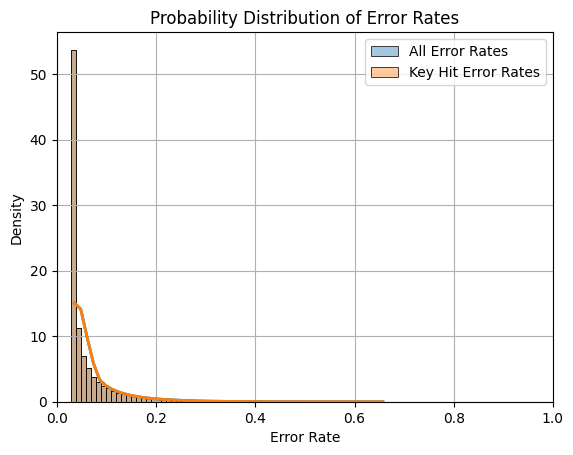

In [353]:
# Plot histogram of error rates and key hit error rates
# Plot probability distribution of error rates (density) with smoothed curves
import matplotlib.pyplot as plt
import seaborn as sns

data_all = np.asarray(gathered_results['error_rate'])
data_key = np.asarray(gathered_results['key_hit_error_rate'])

print("Average Error Rate (All): ", np.mean(data_all))
print("Average Error Rate (Key Hit): ", np.mean(data_key))

bins = 50
# Plot histograms as density
sns.histplot(data_all, binwidth=0.01, stat='density', alpha=0.4, label='All Error Rates', color='C0')
sns.histplot(data_key, binwidth=0.01, stat='density', alpha=0.4, label='Key Hit Error Rates', color='C1')

# Smooth histograms for overlay
hist_all, edges = np.histogram(data_all, bins=bins, density=True)
hist_key, _ = np.histogram(data_key, bins=edges, density=True)
centers = (edges[:-1] + edges[1:]) / 2

def gaussian_smooth(y, sigma=1.5):
    size = max(3, int(4*sigma+1))
    x = np.arange(size) - size//2
    kernel = np.exp(-0.5*(x/sigma)**2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode='same')

plt.plot(centers, gaussian_smooth(hist_all), color='C0', lw=2)
plt.plot(centers, gaussian_smooth(hist_key), color='C1', lw=2)

plt.xlabel('Error Rate')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend()
plt.title('Probability Distribution of Error Rates')
plt.grid(True)
plt.show()

Consensus Ratios:  0.04501238458824608


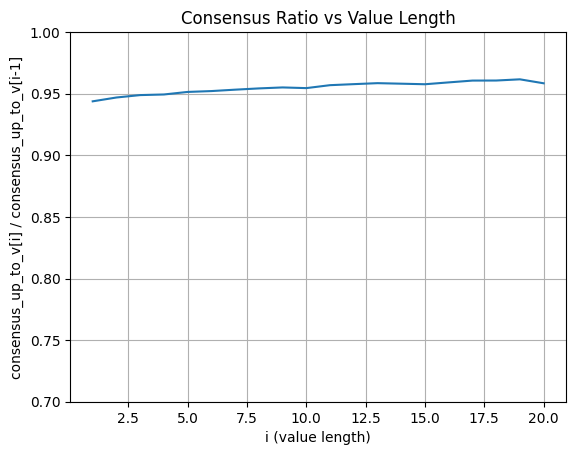

In [354]:
# Plot consensus_up_to_v[i] / consensus_up_to_v[i-1]
import matplotlib.pyplot as plt

ratios = []
for i in range(1, len(gathered_results['consensus_up_to_v'])):
    if gathered_results['consensus_up_to_v'][i-1] == 0:
        ratios.append(0)
    else:
        ratios.append(gathered_results['consensus_up_to_v'][i] / gathered_results['consensus_up_to_v'][i-1])
    
print("Consensus Ratios: ", 1 - np.mean(ratios))
    
plt.plot(range(1, len(gathered_results['consensus_up_to_v'])), ratios)
plt.xlabel('i (value length)')
plt.ylabel('consensus_up_to_v[i] / consensus_up_to_v[i-1]')
plt.title('Consensus Ratio vs Value Length')
plt.ylim(0.7, 1)
plt.grid()
plt.show()

Quadratic fit coefficients: [0.03883875 0.06352172]


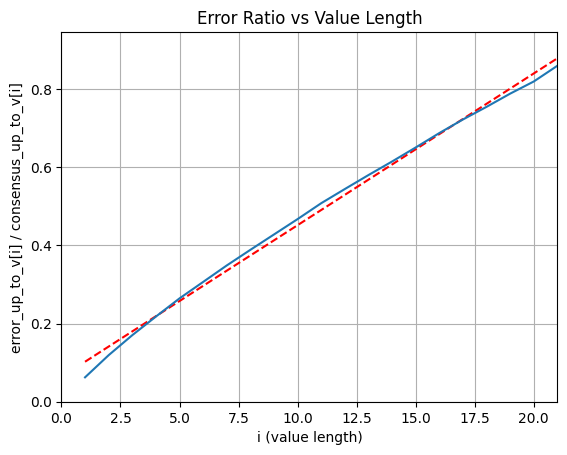

[0.06242829 0.1191508  0.17031014 0.2179447  0.26446565 0.3065988
 0.34877793 0.38877259 0.42811855 0.4674702  0.5081662  0.54443017
 0.58017973 0.61488796 0.65078339 0.6876593  0.72242914 0.75479905
 0.78859688 0.81970779 0.8600299 ]


In [357]:
# Plot error_up_to_v[i] / consensus_up_to_v[i]
error_ratios = []
for i in range(len(gathered_results['error_up_to_v'])):
    if gathered_results['consensus_up_to_v'][i] == 0:
        error_ratios.append(0)
    else:
        error_ratios.append(gathered_results['error_up_to_v'][i] / gathered_results['consensus_up_to_v'][i])
# fit a linear regression after the loop
x = np.arange(len(gathered_results['error_up_to_v'])) + 1
y = np.array(error_ratios)
coefficients = np.polyfit(x, y, 1)
print(f'Quadratic fit coefficients: {coefficients}')
y_pred = np.polyval(coefficients, x)
plt.plot(x, y_pred, color='red', linestyle='--', label=f'Quadratic fit')
plt.plot(np.arange(len(gathered_results['error_up_to_v'])) + 1, error_ratios)
plt.xlabel('i (value length)')
plt.ylabel('error_up_to_v[i] / consensus_up_to_v[i]')
plt.title('Error Ratio vs Value Length')
plt.grid()
plt.xlim(0, np.max(x))
plt.ylim(0, np.max(error_ratios) * 1.1)
plt.show()

print(y)

In [59]:
1 / (1 + 0.05659376174018003)

0.9464375393935966

Text(0.5, 1.0, 'y vs. v')

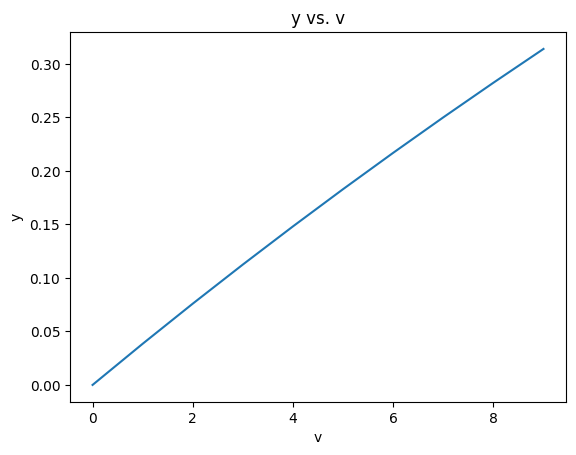

In [328]:
alpha=error_rate * mult
beta=(1 - error_rate) * mult

k = 31 
v = np.arange(10)
y_values = v * alpha / (beta + v + k - 1)

# Plot y vs. v
import matplotlib.pyplot as plt
plt.plot(v, y_values)
plt.xlabel('v')
plt.ylabel('y')
plt.title('y vs. v')


In [325]:
v

array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407